# 301 — Henry Hub Price vs Storage

**Goal:** Explore the relationship between EIA weekly storage and Henry Hub spot price — the most fundamental supply/demand signal in US gas markets.

**Series used:**
- `data/raw/henry_hub_daily.csv` — resampled to weekly mean
- `data/raw/eia_storage_weekly.csv` — storage level + surplus/deficit vs historical avg

In [1]:
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "data" / "raw").exists() and (parent / "notebooks").exists():
            project_root = parent
            break

print("Project root:", project_root)

Project root: C:\Users\alexd\Desktop\GIC\Prep\NatGasModel_US


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(context="paper", font_scale=2.0, style="whitegrid")

DIAG = project_root / "diagram" / "301_price_vs_storage"
DIAG.mkdir(parents=True, exist_ok=True)

## 1. Load & Align

Henry Hub is daily, storage is weekly. Resample price to weekly mean so both series share the same index before joining.

In [8]:
# --- Henry Hub: daily → weekly mean ---
price_raw = pd.read_csv(
    project_root / 'data' / 'raw' / 'henry_hub_daily.csv',
    index_col='date', parse_dates=True
)['henry_hub_price'].astype(float)

price_weekly = price_raw.resample('W-FRI').mean()  # anchor to Friday to match EIA storage dates

# --- Storage: already weekly ---
storage_raw = pd.read_csv(
    project_root / 'data' / 'raw' / 'eia_storage_weekly.csv',
    index_col='date', parse_dates=True
)['storage_bcf'].astype(float)

# --- Surplus / deficit vs historical weekly mean ---
storage_df = storage_raw.to_frame(name='storage_bcf')
storage_df['week'] = storage_df.index.isocalendar().week.astype(int)
weekly_mean = storage_df.groupby('week')['storage_bcf'].mean()
storage_df['avg_bcf']     = storage_df['week'].map(weekly_mean)
storage_df['surplus_bcf'] = storage_df['storage_bcf'] - storage_df['avg_bcf']

# --- Align using merge_asof (matches nearest date within 3 days) ---
price_df   = price_weekly.reset_index().rename(columns={'henry_hub_price': 'price'})
storage_df = storage_df.reset_index()

df = pd.merge_asof(
    storage_df.sort_values('date'),
    price_df.sort_values('date'),
    on='date',
    tolerance=pd.Timedelta(days=3),
    direction='nearest',
).set_index('date').dropna()

# Injection season flag (weeks 16–43 = April–October)
df['week']      = df.index.isocalendar().week.astype(int)
df['injection'] = df['week'].between(16, 43)

print(f"Aligned date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Observations:       {len(df):,}")
df.head()

Aligned date range: 2010-01-01 → 2026-03-20
Observations:       847


,storage_bcf,week,avg_bcf,surplus_bcf,price,injection
date,,,,,,
2010-01-01,3117.0,53,3363.333333,-246.333333,5.880,False
2010-01-08,2850.0,1,3097.176471,-247.176471,6.564,False
2010-01-15,2607.0,2,2920.823529,-313.823529,5.676,False
2010-01-22,2521.0,3,2749.117647,-228.117647,5.560,False
2010-01-29,2406.0,4,2569.941176,-163.941176,5.474,False


## 2. Price & Storage Through Time

Plot both series on a dual-axis chart to see their joint history — do price spikes coincide with storage drawdowns?

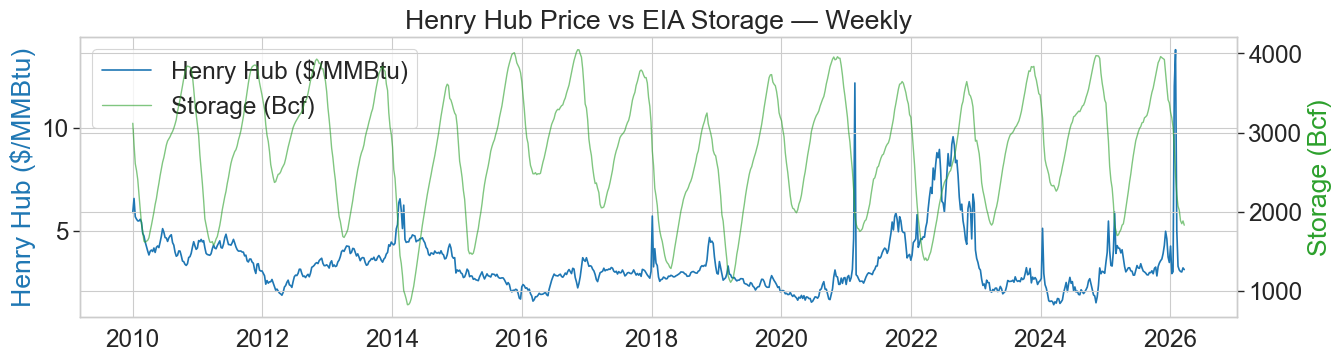

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(df.index, df["price"],       color="tab:blue",  linewidth=1.2, label="Henry Hub ($/MMBtu)")
ax2.plot(df.index, df["storage_bcf"], color="tab:green", linewidth=1.0, alpha=0.6, label="Storage (Bcf)")

ax1.set_ylabel("Henry Hub ($/MMBtu)", color="tab:blue")
ax2.set_ylabel("Storage (Bcf)",       color="tab:green")
ax1.set_xlabel("")
ax1.set_title("Henry Hub Price vs EIA Storage — Weekly")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "price_vs_storage_history.svg", format="svg", bbox_inches="tight")
plt.show()

## 3. Scatter — Storage Level vs Price

Direct scatter of storage level vs price, coloured by season (injection = green, withdrawal = red). If storage explains price, we expect a negative slope — more gas in storage, lower price.

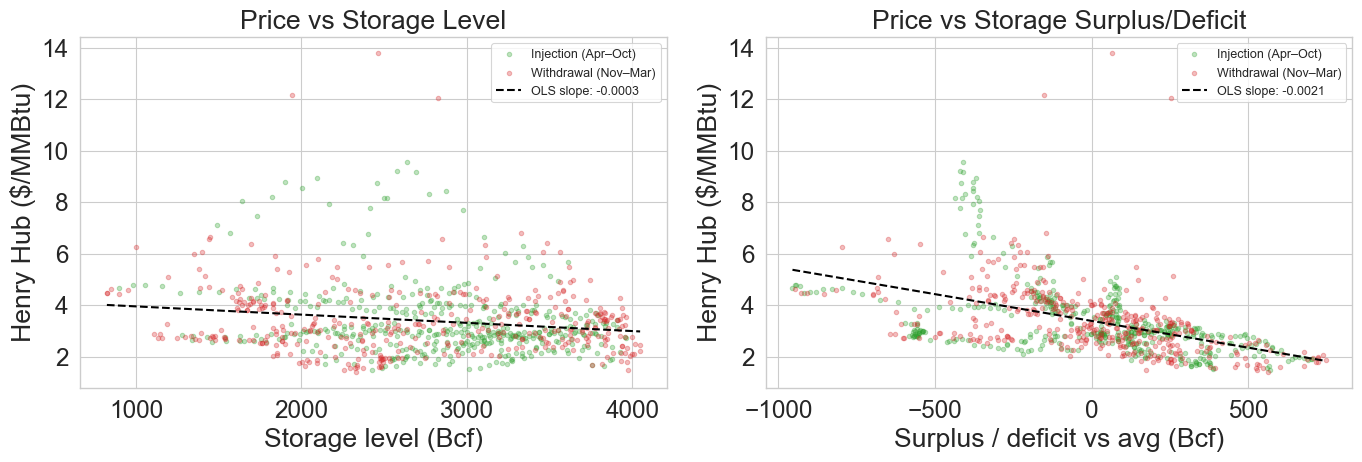

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_col, xlabel in zip(
    axes,
    ["storage_bcf", "surplus_bcf"],
    ["Storage level (Bcf)", "Surplus / deficit vs avg (Bcf)"]
):
    for season, label, color in [
        (True,  "Injection (Apr–Oct)", "tab:green"),
        (False, "Withdrawal (Nov–Mar)", "tab:red"),
    ]:
        subset = df[df["injection"] == season]
        ax.scatter(subset[x_col], subset["price"], alpha=0.3, s=10, color=color, label=label)

    # OLS trend line
    x = df[x_col].values
    y = df["price"].values
    m, b = np.polyfit(x, y, 1)
    ax.plot(np.sort(x), m * np.sort(x) + b, color="black", linewidth=1.5, linestyle="--", label=f"OLS slope: {m:.4f}")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Henry Hub ($/MMBtu)")
    ax.legend(fontsize=9)

axes[0].set_title("Price vs Storage Level")
axes[1].set_title("Price vs Storage Surplus/Deficit")

fig.tight_layout()
fig.savefig(DIAG / "price_vs_storage_scatter.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Correlation

Pearson correlation between price and both storage measures. Also compute rolling 52-week correlation to see whether the relationship is stable over time or breaks down in certain regimes.

Correlation — price vs storage level:   -0.172
Correlation — price vs surplus/deficit: -0.489


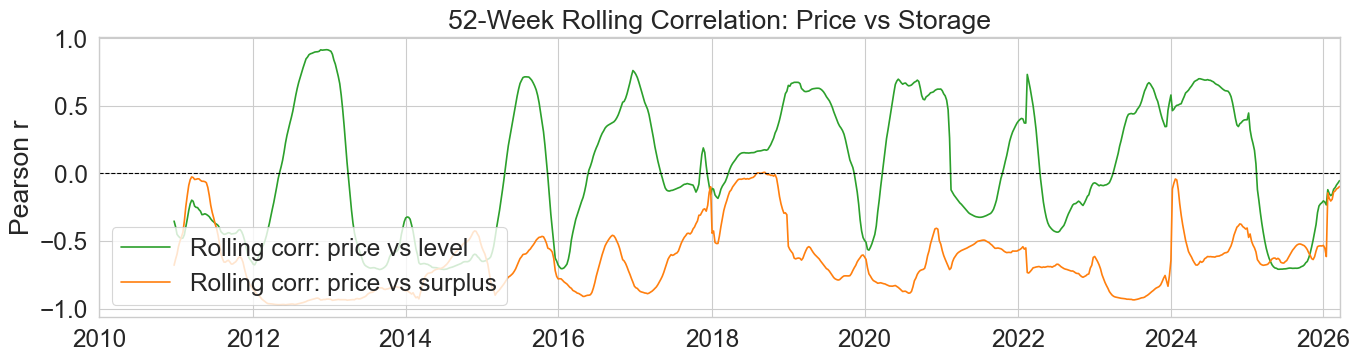

In [11]:
# Static correlations
corr_level   = df["price"].corr(df["storage_bcf"])
corr_surplus = df["price"].corr(df["surplus_bcf"])

print(f"Correlation — price vs storage level:   {corr_level:.3f}")
print(f"Correlation — price vs surplus/deficit: {corr_surplus:.3f}")

# Rolling 52-week correlation
rolling_corr_level   = df["price"].rolling(52).corr(df["storage_bcf"])
rolling_corr_surplus = df["price"].rolling(52).corr(df["surplus_bcf"])

fig, ax = plt.subplots(figsize=(14, 4))

rolling_corr_level.plot(ax=ax,   color="tab:green", linewidth=1.2, label="Rolling corr: price vs level")
rolling_corr_surplus.plot(ax=ax, color="tab:orange", linewidth=1.2, label="Rolling corr: price vs surplus")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_title("52-Week Rolling Correlation: Price vs Storage")
ax.set_ylabel("Pearson r")
ax.set_xlabel("")
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(DIAG / "price_vs_storage_rolling_corr.svg", format="svg", bbox_inches="tight")
plt.show()

## 5. Lead / Lag Analysis

Does storage *lead* price (storage changes first, price follows) or does price *lead* storage (market prices in the shift before EIA confirms it)? Cross-correlation at lags of ±12 weeks.

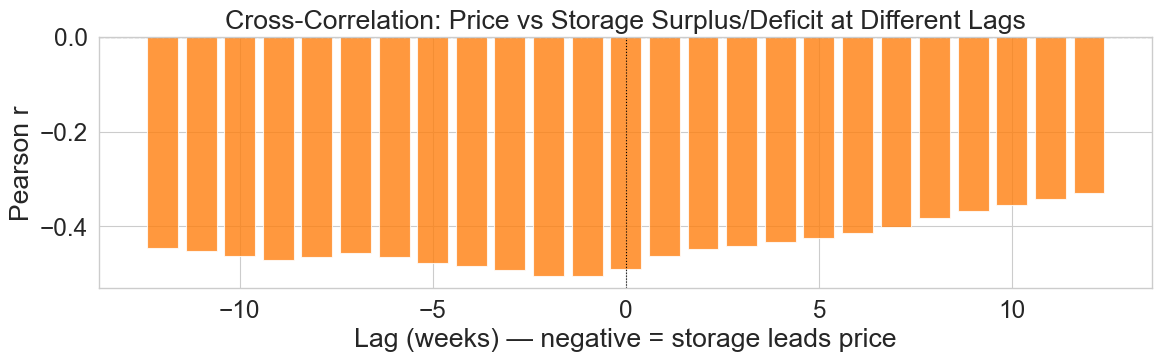

Strongest correlation at lag -1 weeks (r = -0.505)


In [12]:
lags = range(-12, 13)  # negative = storage leads price, positive = price leads storage
corrs = [df["price"].corr(df["surplus_bcf"].shift(lag)) for lag in lags]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(lags, corrs, color=["tab:orange" if c < 0 else "tab:blue" for c in corrs], alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Lag (weeks) — negative = storage leads price")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-Correlation: Price vs Storage Surplus/Deficit at Different Lags")

fig.tight_layout()
fig.savefig(DIAG / "price_vs_storage_leadlag.svg", format="svg", bbox_inches="tight")
plt.show()

best_lag = list(lags)[np.argmax(np.abs(corrs))]
print(f"Strongest correlation at lag {best_lag} weeks (r = {corrs[best_lag + 12]:.3f})")

## 6. Observations

### Correlation results

| Measure | Pearson r | Interpretation |
|---|---|---|
| Price vs storage level | -0.172 | Weak — raw level is a poor predictor |
| Price vs surplus/deficit | -0.489 | Moderate — stripping seasonality reveals the real signal |

The raw storage level is a weak predictor because it carries a strong seasonal cycle — 1,000 Bcf in March and 1,000 Bcf in October mean completely different things to the market. Comparing raw levels without seasonal context adds noise, not signal.

The surplus/deficit removes that seasonal noise and isolates whether the market is structurally tight or loose. The correlation nearly triples (-0.172 → -0.489), confirming that **what matters is not how much gas is in storage, but how much relative to what is normal for that time of year**.

r² ≈ 0.24, meaning surplus/deficit alone explains roughly 24% of price variance. The remaining ~76% is driven by temperature, production levels, LNG export demand, and macro sentiment. Storage is important but not sufficient on its own.

---

### Lead/lag results

- Strongest correlation at **lag -1 week** (r = -0.505)
- Pearson increases from lag -2 onward, with the curve skewed toward negative lags

A negative lag means **storage leads price** — the storage level changes one week before price fully reflects it. This aligns with the EIA reporting cycle: the Thursday print updates the market's view, and price adjusts over the following week ahead of the next release.

The skew toward negative lags (storage → price, not price → storage) confirms storage is genuinely informative — the market does not instantaneously price in the full storage signal. There is a one-week window where surplus/deficit has predictive power for price direction.

This is not a free arbitrage — the 1-week lag is at the frequency of the EIA release itself, meaning you would need to act on Thursday's number before the following Thursday to exploit it.

---

### Market interpretation

Storage surplus/deficit is a real but incomplete price signal. It should enter the model as a feature, but always alongside temperature (HDD/CDD), which drives the demand side. A large storage surplus combined with an abnormally cold week ahead is a very different situation from the same surplus during a mild shoulder month — storage needs weather context to be actionable.